In [1]:
import numpy as np
from pathlib import Path
import os
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras import layers, models, callbacks
%matplotlib inline

In [2]:
BASE = Path(r"C:\Users\Shristi\OneDrive\Desktop\SisFall Gait stability\archive (6)\Three Classes")
assert BASE.exists(), f"BASE not found: {BASE}"

In [3]:
def ensure_raw_float32_npy(xfile: Path):
    """Return path to .raw_float32.npy or .npy for the given xfile name.
       If original is binary raw floats, create .raw_float32.npy. If np.load works, save direct .npy."""
    raw_npy = xfile.with_suffix('.raw_float32.npy')
    npy_direct = xfile.with_suffix('.npy')
    if npy_direct.exists():
        return npy_direct
    if raw_npy.exists():
        return raw_npy
    # try np.load first (in case file is already .npy masked by extension)
    try:
        arr = np.load(xfile, allow_pickle=True)
        # if arr is multi-dim we can save as .npy
        if getattr(arr, 'ndim', 1) != 1:
            np.save(npy_direct, arr)
            print(f"Saved direct .npy from np.load: {npy_direct} shape {arr.shape}")
            return npy_direct
    except Exception:
        pass
    # fallback: fromfile float32 -> save raw_float32.npy
    raw = np.fromfile(xfile, dtype=np.float32)
    np.save(raw_npy, raw)
    print(f"Created {raw_npy} (1-D float32) length {raw.size}")
    return raw_npy

In [4]:
def load_labels_onehot_uint8(yfile: Path, n_classes=3):
    """Load label file stored as one-hot bytes (uint8 triplets). Returns int class indices."""
    if not yfile.exists():
        raise FileNotFoundError(yfile)
    # try np.load first (if already .npy)
    try:
        lab = np.load(yfile, allow_pickle=True)
        arr = np.array(lab).ravel()
        # if arr looks like integer labels already, just return
        uniq = np.unique(arr)
        if arr.dtype != np.uint8 and np.all((uniq < n_classes) & (uniq >= 0)):
            return arr.astype(int).ravel()
    except Exception:
        pass
    # Read raw bytes as uint8
    b = np.fromfile(yfile, dtype=np.uint8)
    # if divisible by n_classes, interpret as one-hot rows
    if b.size % n_classes == 0:
        rows = b.size // n_classes
        onehot = b.reshape(rows, n_classes)
        # sanity check: each row should have exactly one 1
        row_sums = onehot.sum(axis=1)
        # If row sums are mostly 1, use argmax
        if np.mean(row_sums == 1) > 0.95:
            labels = np.argmax(onehot, axis=1).astype(int)
            return labels
    # If above fails, try reading as uint8 but maybe format is single-byte labels (0/1/2)
    if np.all(np.isin(b, [0,1,2])):
        return b.astype(int)
    # As fallback, try other common encodings
    try:
        import pandas as pd
        df = pd.read_csv(yfile, header=None, encoding='latin1')
        arr = df.values.ravel().astype(int)
        return arr
    except Exception:
        pass
    # If still not decoded, raise error
    raise RuntimeError(f"Could not decode label file {yfile}; got {b[:24]} (first bytes)")


In [5]:
# SETTINGS (we deduced these from file sizes)
features = 6    # acc_x,y,z + gyro_x,y,z
# We'll compute window_len = total_floats / (features * num_labels) for each split

# Load/prepare labels
y_train = load_labels_onehot_uint8(BASE/"y_train_3", n_classes=3)
y_val   = load_labels_onehot_uint8(BASE/"y_val_3", n_classes=3)
y_test  = load_labels_onehot_uint8(BASE/"y_test_3", n_classes=3)
print("Loaded label counts -> train:", y_train.size, "val:", y_val.size, "test:", y_test.size)
print("Unique labels (train):", np.unique(y_train))

Loaded label counts -> train: 77871 val: 20233 test: 18884
Unique labels (train): [0 1 2]


In [6]:
xtrain_raw = ensure_raw_float32_npy(BASE/"x_train_3")
xval_raw   = ensure_raw_float32_npy(BASE/"x_val_3")
xtest_raw  = ensure_raw_float32_npy(BASE/"x_test_3")

arr_train_1d = np.load(xtrain_raw)
total_train = arr_train_1d.size
num_labels_train = y_train.size
window_len_train = total_train // (features * num_labels_train)
assert window_len_train * features * num_labels_train == total_train, "Train size not divisible - check labels/features"
print("Train: total floats", total_train, "-> window_len", window_len_train, "features", features)

Train: total floats 119609856 -> window_len 256 features 6


In [7]:
arr_val_1d = np.load(xval_raw)
total_val = arr_val_1d.size
num_labels_val = y_val.size
window_len_val = total_val // (features * num_labels_val)
assert window_len_val * features * num_labels_val == total_val, "Val size not divisible - check labels/features"
print("Val: total floats", total_val, "-> window_len", window_len_val, "features", features)

Val: total floats 31077888 -> window_len 256 features 6


In [8]:
arr_test_1d = np.load(xtest_raw)
total_test = arr_test_1d.size
num_labels_test = y_test.size
window_len_test = total_test // (features * num_labels_test)
assert window_len_test * features * num_labels_test == total_test, "Test size not divisible - check labels/features"
print("Test: total floats", total_test, "-> window_len", window_len_test, "features", features)

Test: total floats 29005824 -> window_len 256 features 6


In [9]:
if not (window_len_train == window_len_val == window_len_test):
    print("Warning: window lengths differ across splits:", window_len_train, window_len_val, window_len_test)

window_len = window_len_train
print("Using window_len =", window_len)

Using window_len = 256


In [10]:
X_train = arr_train_1d.reshape((num_labels_train, window_len, features)).astype('float32')
np.save(BASE/"x_train_3.npy", X_train)
print("Saved x_train_3.npy shape:", X_train.shape)

X_val = arr_val_1d.reshape((num_labels_val, window_len, features)).astype('float32')
np.save(BASE/"x_val_3.npy", X_val)
print("Saved x_val_3.npy shape:", X_val.shape)

X_test = arr_test_1d.reshape((num_labels_test, window_len, features)).astype('float32')
np.save(BASE/"x_test_3.npy", X_test)
print("Saved x_test_3.npy shape:", X_test.shape)

Saved x_train_3.npy shape: (77871, 256, 6)
Saved x_val_3.npy shape: (20233, 256, 6)
Saved x_test_3.npy shape: (18884, 256, 6)


In [11]:
np.save(BASE/"y_train_3.npy", y_train.astype('int'))
np.save(BASE/"y_val_3.npy", y_val.astype('int'))
np.save(BASE/"y_test_3.npy", y_test.astype('int'))
print("Saved y_*.npy files.")

Saved y_*.npy files.


In [12]:
print("Sanity shapes: X_train", X_train.shape, "y_train", y_train.shape)
print("Unique labels:", np.unique(y_train))

Sanity shapes: X_train (77871, 256, 6) y_train (77871,)
Unique labels: [0 1 2]


In [13]:
n_classes = len(np.unique(y_train))
print("n_classes:", n_classes)

n_classes: 3


In [14]:
def build_model(input_shape, n_classes):
    model = models.Sequential([
        layers.Input(input_shape),
        layers.Masking(mask_value=0.0),
        layers.LSTM(128, return_sequences=True),
        layers.Dropout(0.3),
        layers.LSTM(64),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dense(n_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [15]:
X_train = np.load(BASE/"x_train_3.npy")
X_val   = np.load(BASE/"x_val_3.npy")
X_test  = np.load(BASE/"x_test_3.npy")
y_train = np.load(BASE/"y_train_3.npy").astype('int').ravel()
y_val   = np.load(BASE/"y_val_3.npy").astype('int').ravel()
y_test  = np.load(BASE/"y_test_3.npy").astype('int').ravel()

print("Final loaded shapes for training:", X_train.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape, y_test.shape)

model = build_model(X_train.shape[1:], n_classes)
model.summary()

ckpt = callbacks.ModelCheckpoint(str(BASE/"best_lstm.h5"), save_best_only=True, monitor='val_accuracy', mode='max')
early = callbacks.EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True)

hist = model.fit(X_train, y_train, validation_data=(X_val,y_val), epochs=10, batch_size=64, callbacks=[ckpt, early])


Final loaded shapes for training: (77871, 256, 6) (77871,) (20233, 256, 6) (20233,) (18884, 256, 6) (18884,)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ masking (Masking)                    │ (None, 256, 6)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 256, 128)            │          69,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256, 128)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 122,883 (480.01 KB)

 Trainable params: 122,883 (480.01 KB)

...

1217/1217 ━━━━━━━━━━━━━━━━━━━━ 1020s 821ms/step - accuracy: 0.9625 - loss: 0.1628 - val_accuracy: 0.9644 - val_loss: 0.1534
Epoch 7/10
1217/1217 ━━━━━━━━━━━━━━━━━━━━ 0s 761ms/step - accuracy: 0.9712 - loss: 0.1202   

1217/1217 ━━━━━━━━━━━━━━━━━━━━ 1002s 823ms/step - accuracy: 0.9715 - loss: 0.1165 - val_accuracy: 0.9715 - val_loss: 0.1147
Epoch 8/10
1217/1217 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9759 - loss: 0.0958      

1217/1217 ━━━━━━━━━━━━━━━━━━━━ 1517s 1s/step - accuracy: 0.9762 - loss: 0.0927 - val_accuracy: 0.9751 - val_loss: 0.0834
Epoch 9/10
1217/1217 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9779 - loss: 0.0801   

1217/1217 ━━━━━━━━━━━━━━━━━━━━ 2264s 2s/step - accuracy: 0.9778 - loss: 0.0783 - val_accuracy: 0.9773 - val_loss: 0.0747
Epoch 10/10
1217/1217 ━━━━━━━━━━━━━━━━━━━━ 0s 799ms/step - accuracy: 0.9791 - loss: 0.0711   

1217/1217 ━━━━━━━━━━━━━━━━━━━━ 1054s 866ms/step - accuracy: 0.9793 - loss: 0.0685 - val_accuracy: 0.9784 - val_loss: 0.0716


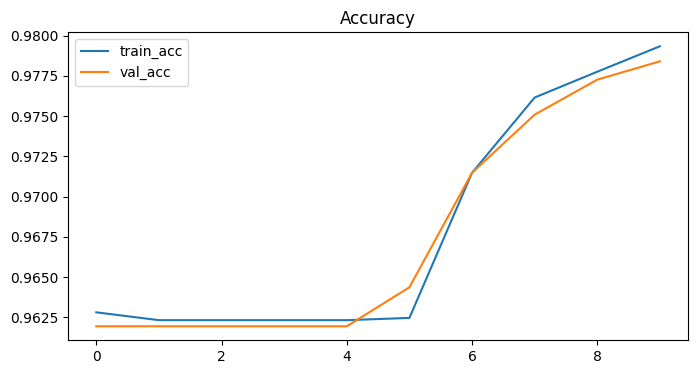

In [16]:
plt.figure(figsize=(8,4))
plt.plot(hist.history['accuracy'], label='train_acc')
plt.plot(hist.history['val_accuracy'], label='val_acc')
plt.legend(); plt.title('Accuracy'); plt.show()

In [17]:
probs = model.predict(X_test, batch_size=256)
preds = probs.argmax(axis=1)
print("Test accuracy:", accuracy_score(y_test, preds))
print("Classification report:\n", classification_report(y_test, preds, digits=4))

74/74 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step 
Test accuracy: 0.9804066934971405
Classification report:
               precision    recall  f1-score   support

           0     0.9831    0.9973    0.9902     18180
           1     0.0000    0.0000    0.0000       157
           2     0.8665    0.7002    0.7745       547

    accuracy                         0.9804     18884
   macro avg     0.6166    0.5658    0.5882     18884
weighted avg     0.9716    0.9804    0.9757     18884



C:\Users\Shristi\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Shristi\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Shristi\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz

Confusion matrix (counts):


array([[18131,     0,    49],
       [  147,     0,    10],
       [  164,     0,   383]])

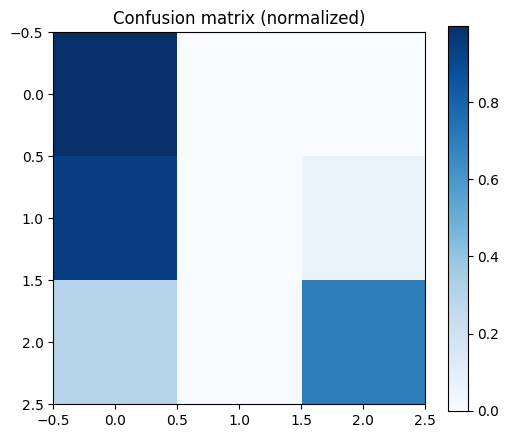

In [18]:
cm = confusion_matrix(y_test, preds)
print("Confusion matrix (counts):"); display(cm)
plt.figure(figsize=(6,5)); plt.imshow(cm.astype('float')/(cm.sum(axis=1)[:,None]+1e-9), cmap='Blues'); plt.title('Confusion matrix (normalized)'); plt.colorbar(); plt.show()

In [19]:
model.save(BASE/"final_lstm.h5")
print("Saved final model to:", BASE/"final_lstm.h5")

Saved final model to: C:\Users\Shristi\OneDrive\Desktop\SisFall Gait stability\archive (6)\Three Classes\final_lstm.h5
